# EDA Demo: Exploring ODOT Crash Data

by Liming Wang  04/30/2026

USP 410/510 Urban Data Science — Week 5

Companion notebook for `week5_slides.md`. Walk through an EDA pass on the 2023 Oregon crash data.

**EDA loop**: `question → group/filter → plot → read it → next question`

## 0. Setup

In [1]:
%pip install geopandas pandas seaborn plotly


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

In [3]:
crashes = gpd.read_file("data/Statewide_Crashes_2023.gdb", layer="crashes2023")
crashes["CRASH_DT"] = pd.to_datetime(crashes["CRASH_DT"])
crashes["CITY_SECT_NM"] = crashes["CITY_SECT_NM"].str.strip().str.upper()

# Several columns come in as strings — coerce to numeric for plotting and stats
for col in ["CRASH_HR_NO", "POST_SPEED_LMT_VAL", "TOT_INJ_CNT", "TOT_FATAL_CNT"]:
    crashes[col] = pd.to_numeric(crashes[col], errors="coerce")

crashes["HOUR"] = crashes["CRASH_HR_NO"].where(crashes["CRASH_HR_NO"].between(0, 23))
crashes["SEV"] = crashes["CRASH_SVRTY_CD"].map({"5": "PDO", "4": "Injury", "2": "Fatal"})
crashes["DOW"] = crashes["CRASH_DT"].dt.day_name()
crashes["MONTH"] = crashes["CRASH_DT"].dt.month
print(f"{len(crashes):,} crashes, {crashes.shape[1]} columns")

46,762 crashes, 145 columns


## 1. Univariate Sweep

**Question**: What does each key column look like on its own?

In [4]:
crashes["CRASH_SVRTY_LONG_DESC"].value_counts(dropna=False)

CRASH_SVRTY_LONG_DESC
Non-Fatal Injury        24790
Property Damage Only    21438
Fatal                     534
Name: count, dtype: int64

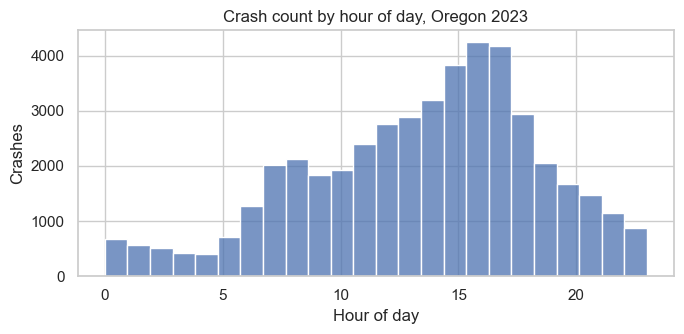

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(crashes, x="HOUR", bins=24, ax=ax)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Crashes")
ax.set_title("Crash count by hour of day, Oregon 2023")
fig.tight_layout()

In [6]:
crashes['HOUR'].dtype

dtype('float64')

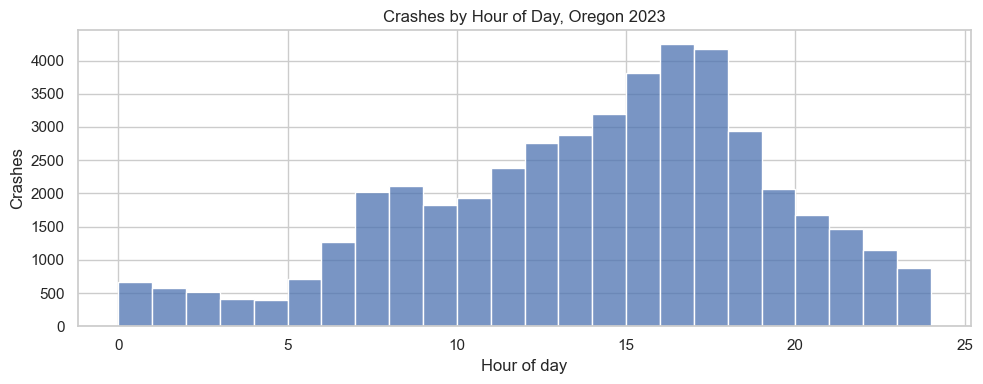

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(pd.to_numeric(crashes["HOUR"], errors="coerce").dropna().astype(int),
             bins=range(25), ax=ax)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Crashes")
ax.set_title("Crashes by Hour of Day, Oregon 2023")
fig.tight_layout()

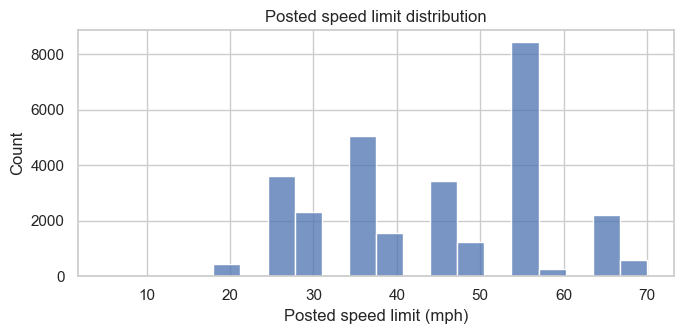

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(crashes, x="POST_SPEED_LMT_VAL", bins=20, ax=ax)
ax.set_xlabel("Posted speed limit (mph)")
ax.set_title("Posted speed limit distribution")
fig.tight_layout()

How do you fix the Posted speed limit plot?

Watch for spikes at sentinel values (e.g., `99`, `0`) — usually missing in disguise.

## 2. Time-of-Day and Day-of-Week Patterns

**Question**: When do crashes happen?

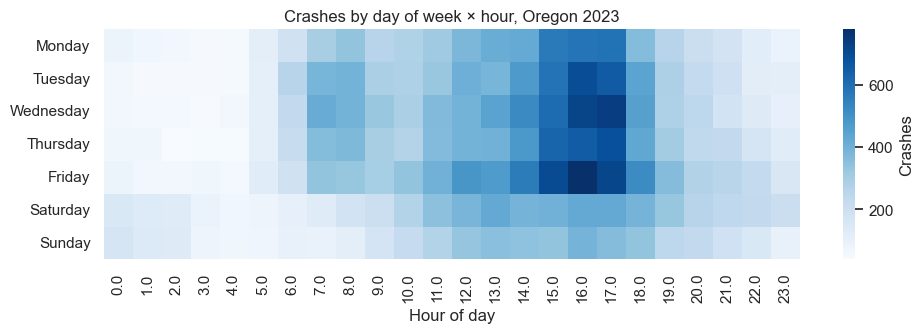

In [9]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_dow = (
    crashes.dropna(subset=["HOUR"])
    .groupby(["DOW", "HOUR"]).size()
    .unstack("HOUR", fill_value=0)
    .reindex(dow_order)
)
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(hour_dow, cmap="Blues", cbar_kws={"label": "Crashes"}, ax=ax)
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
ax.set_title("Crashes by day of week × hour, Oregon 2023")
fig.tight_layout()

## 3. Severity by Weather and Surface Conditions

**Question**: Are severe outcomes more common in adverse conditions?

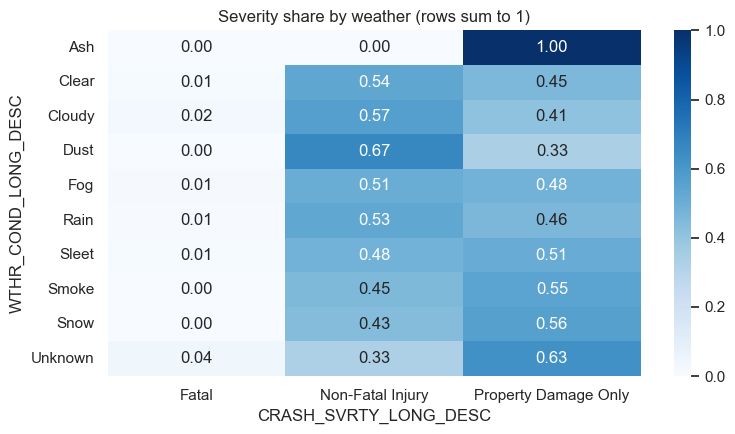

In [10]:
ct = pd.crosstab(
    crashes["WTHR_COND_LONG_DESC"],
    crashes["CRASH_SVRTY_LONG_DESC"],
    normalize="index",
)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Severity share by weather (rows sum to 1)")
fig.tight_layout()

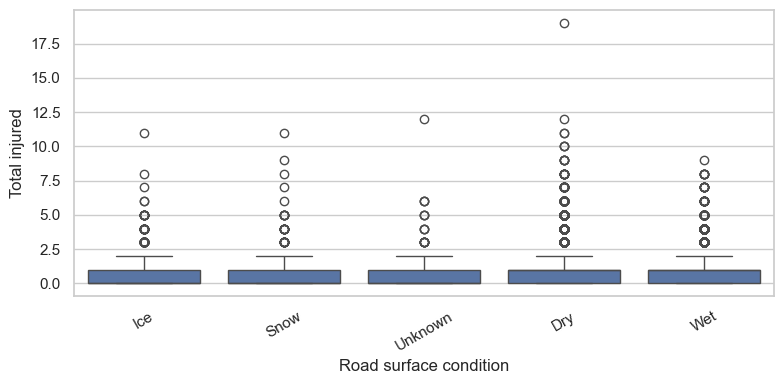

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
order = (
    crashes.groupby("RD_SURF_MED_DESC")["TOT_INJ_CNT"].median()
    .sort_values().index.tolist()
)
sns.boxplot(crashes, x="RD_SURF_MED_DESC", y="TOT_INJ_CNT", order=order, ax=ax)
ax.set_xlabel("Road surface condition")
ax.set_ylabel("Total injured")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

## 4. Speed Limit vs Injuries

**Question**: Do higher posted speed limits correlate with more injuries per crash?

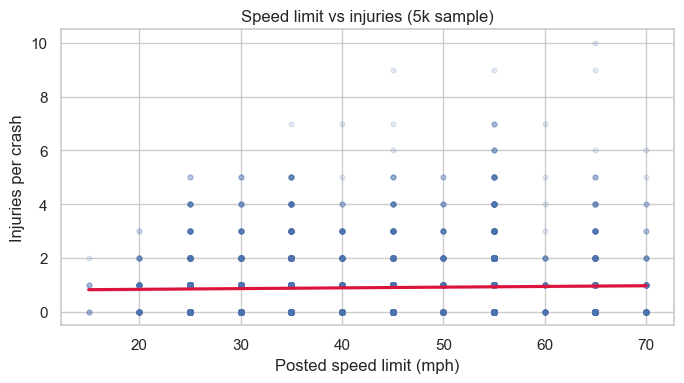

In [12]:
subset = crashes.dropna(subset=["POST_SPEED_LMT_VAL", "TOT_INJ_CNT"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(
    subset.sample(min(5000, len(subset)), random_state=0),
    x="POST_SPEED_LMT_VAL", y="TOT_INJ_CNT",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_xlabel("Posted speed limit (mph)")
ax.set_ylabel("Injuries per crash")
ax.set_title("Speed limit vs injuries (5k sample)")
fig.tight_layout()

In [13]:
by_speed = (
    crashes.dropna(subset=["POST_SPEED_LMT_VAL"])
    .groupby("POST_SPEED_LMT_VAL")
    .agg(crashes=("CRASH_ID", "count"),
         mean_inj=("TOT_INJ_CNT", "mean"),
         fatal_rate=("TOT_FATAL_CNT", "mean"))
)
by_speed

,crashes,mean_inj,fatal_rate
POST_SPEED_LMT_VAL,,,
5.0,1,0.000000,0.000000
10.0,7,0.285714,0.000000
15.0,46,0.652174,0.000000
20.0,456,0.728070,0.004386
25.0,3604,0.737236,0.004717
30.0,2312,0.912630,0.013841
35.0,5048,0.963154,0.012678
40.0,1552,1.037371,0.013531
45.0,3422,1.019579,0.012566


## 5. One Polished Chart

Move from exploratory to explanatory: a single chart suitable for a report.

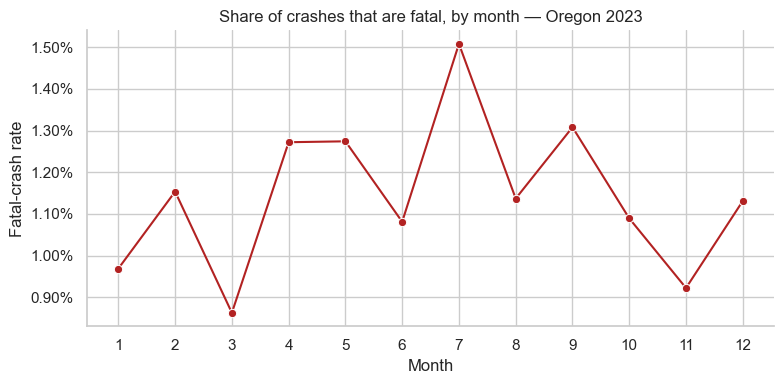

In [14]:
monthly = (
    crashes.assign(is_fatal=crashes["TOT_FATAL_CNT"] > 0)
    .groupby("MONTH")
    .agg(crashes=("CRASH_ID", "count"),
         fatal_crashes=("is_fatal", "sum"))
    .assign(fatal_rate=lambda d: d["fatal_crashes"] / d["crashes"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(monthly, x="MONTH", y="fatal_rate", marker="o", ax=ax, color="#b22222")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Fatal-crash rate")
ax.set_title("Share of crashes that are fatal, by month — Oregon 2023")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig("outputs/fatal_rate_by_month.png", dpi=150)

## 6. Interactive Plotly Map → HTML

Preview of Week 7 spatial work. Export as standalone HTML so anyone can open it in a browser.

In [18]:
geo = crashes.to_crs(4326)
geo["LON"] = geo.geometry.x
geo["LAT"] = geo.geometry.y

portland = geo[geo["CITY_SECT_NM"].str.contains("PORTLAND", na=False)]
sample = portland.sample(min(2000, len(portland)), random_state=0)

fig = px.scatter_map(
    sample,
    lat="LAT", lon="LON",
    color="CRASH_SVRTY_LONG_DESC",
    hover_data=["CRASH_DT", "WTHR_COND_LONG_DESC", "POST_SPEED_LMT_VAL"],
    zoom=10,
    height=520,
    title="Portland-area crashes (sample of 2,000) — 2023",
)
fig.update_layout(margin={"l": 0, "r": 0, "t": 40, "b": 0})
#fig.write_html("outputs/portland_crashes_2023.html")
fig

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[Timestamp('2023-04-27 00:00:00'), 'Clear', 30.0],
                                   [Timestamp('2023-11-20 00:00:00'), 'Unknown', nan],
                                   [Timestamp('2023-06-27 00:00:00'), 'Clear', nan],
                                   ...,
                                   [Timestamp('2023-08-19 00:00:00'), 'Clear', 35.0],
                                   [Timestamp('2023-06-01 00:00:00'), 'Clear', 30.0],
                                   [Timestamp('2023-06-19 00:00:00'), 'Rain', nan]],
                                  shape=(1073, 3), dtype=object),
              'hovertemplate': ('CRASH_SVRTY_LONG_DESC=Non-Fata' ... '{customdata[2]}<extra></extra>'),
              'lat': {'bdata': ('S259tKq/RkARFQ9/6sJGQHqbb66Awk' ... 'KjzEZACpJWi4u/RkAlmThjVL1GQA=='),
                      'dtype': 'f8'},
              'legendgroup': 'Non-Fatal Injury',
              'lon': {'bdata': ('6ihpxYSkXsBR2JI/D6VewCpnDaBDq1' ... '5Ksl7ArQN3ASijXsB8Cuo616xewA=='),
                      'dtype': 'f8'},
              'marker': {'color': '#636efa'},
              'mode': 'markers',
              'name': 'Non-Fatal Injury',
              'showlegend': True,
              'subplot': 'map',
              'type': 'scattermap'},
             {'customdata': array([[Timestamp('2023-01-15 00:00:00'), 'Clear', nan],
                                   [Timestamp('2023-06-21 00:00:00'), 'Clear', nan],
                                   [Timestamp('2023-05-10 00:00:00'), 'Clear', nan],
                                   ...,
                                   [Timestamp('2023-07-31 00:00:00'), 'Clear', 50.0],
                                   [Timestamp('2023-08-31 00:00:00'), 'Rain', nan],
                                   [Timestamp('2023-04-19 00:00:00'), 'Clear', 45.0]],
                                  shape=(910, 3), dtype=object),
              'hovertemplate': ('CRASH_SVRTY_LONG_DESC=Property' ... '{customdata[2]}<extra></extra>'),
              'lat': {'bdata': ('QWrMqKW8RkC9n4o4W8RGQFECsno4yU' ... 'l80MRGQFECsno4yUZAzIrpaO6/RkA='),
                      'dtype': 'f8'},
              'legendgroup': 'Property Damage Only',
              'lon': {'bdata': ('qpJw/Z2fXsB2zFeV/qdewNU2rB0Up1' ... 'powqtewNU2rB0Up17A439XHD+qXsA='),
                      'dtype': 'f8'},
              'marker': {'color': '#EF553B'},
              'mode': 'markers',
              'name': 'Property Damage Only',
              'showlegend': True,
              'subplot': 'map',
              'type': 'scattermap'},
             {'customdata': array([[Timestamp('2023-01-01 00:00:00'), 'Cloudy', 25.0],
                                   [Timestamp('2023-12-25 00:00:00'), 'Rain', 30.0],
                                   [Timestamp('2023-12-25 00:00:00'), 'Rain', 40.0],
                                   [Timestamp('2023-12-04 00:00:00'), 'Rain', 50.0],
                                   [Timestamp('2023-07-05 00:00:00'), 'Clear', nan],
                                   [Timestamp('2023-07-08 00:00:00'), 'Clear', 30.0],
                                   [Timestamp('2023-07-15 00:00:00'), 'Clear', 45.0],
                                   [Timestamp('2023-05-03 00:00:00'), 'Clear', 40.0],
                                   [Timestamp('2023-12-25 00:00:00'), 'Rain', 30.0],
                                   [Timestamp('2023-11-23 00:00:00'), 'Clear', 50.0],
                                   [Timestamp('2023-06-04 00:00:00'), 'Clear', 35.0],
                                   [Timestamp('2023-11-02 00:00:00'), 'Cloudy', 30.0],
                                   [Timestamp('2023-05-11 00:00:00'), 'Clear', 25.0],
                                   [Timestamp('2023-10-14 00:00:00'), 'Rain', nan],
                                   [Timestamp('2023-03-04 00:00:00'), 'Cloudy', 40.0],
                                   [Timestamp('2023-02-26 00:00:00'), 'Unknown', nan],
                                   [Timestamp('202

## Takeaways

- Anchor each cell to a question. If a plot does not answer it, change one of them.
- Inspect distributions before relationships.
- Sentinel values (`99`, `0`) bite — clean before plotting.
- Polish the few charts that earn it; leave the rest rough.
- Export interactive plots to HTML for sharing.